Nous allons charger les données issues de MovieLens. 

In [2]:
import pandas as pd

movies = pd.read_csv('/Users/nazmanazirhussain/Desktop/RecommandationFilm/data/brute/movies.csv')

ratings = pd.read_csv('/Users/nazmanazirhussain/Desktop/RecommandationFilm/data/brute/ratings.csv')

tags = pd.read_csv('/Users/nazmanazirhussain/Desktop/RecommandationFilm/data/brute/tags.csv')

links = pd.read_csv('/Users/nazmanazirhussain/Desktop/RecommandationFilm/data/brute/links.csv')

In [3]:
# Vérification du chargement 

print("Movies : ", movies.shape)

print("Ratings :", ratings.shape)

print("Tags :", tags.shape)

print("Links :", links.shape)

Movies :  (9742, 3)
Ratings : (100836, 4)
Tags : (3683, 4)
Links : (9742, 3)


In [4]:
# Montrer les premiers lignes de la table "movies"

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
# Montrer les premiers lignes de la table "ratings"

ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [6]:
# Montrer les premiers lignes de la table "tags"

tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [7]:
# Montrer les premiers lignes de la table "links"

links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


Maintenant, on va regarder si les tables contiennent des doublons. 

In [8]:
print("Doublons movies :", movies.duplicated().sum())
print("Doublons ratings :", ratings.duplicated().sum())
print("Doublons tags :", tags.duplicated().sum())
print("Doublons links :", links.duplicated().sum())

Doublons movies : 0
Doublons ratings : 0
Doublons tags : 0
Doublons links : 0


Pour movies : Est-ce qu'un movieID apparaît plusieurs fois ? 

In [9]:
print("movieId dupliqués :", movies['movieId'].duplicated().sum())

movieId dupliqués : 0


Pour ratings : Est-ce qu'un utilisateur a noté deux fois le même film ?

In [10]:
print("Paires (userId, movieId) dupliquées :", ratings.duplicated(subset=['userId', 'movieId']).sum())

Paires (userId, movieId) dupliquées : 0


Pour links : est-ce qu'un movieId apparaît plusieurs fois ?

In [11]:
print("movieId dupliqués dans links :", links['movieId'].duplicated().sum())

movieId dupliqués dans links : 0


On va voir les différents types des colonnes dans les 4 tables. 

In [12]:
movies.dtypes

movieId    int64
title        str
genres       str
dtype: object

In [13]:
ratings.dtypes

userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

In [14]:
tags.dtypes

userId       int64
movieId      int64
tag            str
timestamp    int64
dtype: object

In [15]:
links.dtypes

movieId      int64
imdbId       int64
tmdbId     float64
dtype: object

On peut constater que les colonnes "timestamp" dans les tables "tags" et "ratings" est de type INTEGER. On doit donc créer une colonne dans ces tables pour convertir le timestamp en date. 

In [16]:
# Ajouter une colonne "date" avec le timestamp équivalent (table tags)

tags['date'] = pd.to_datetime(tags['timestamp'], unit='s')
tags.head()

,userId,movieId,tag,timestamp,date
0,2,60756,funny,1445714994,2015-10-24 19:29:54
1,2,60756,Highly quotable,1445714996,2015-10-24 19:29:56
2,2,60756,will ferrell,1445714992,2015-10-24 19:29:52
3,2,89774,Boxing story,1445715207,2015-10-24 19:33:27
4,2,89774,MMA,1445715200,2015-10-24 19:33:20


In [17]:
# Ajouter une colonne "date" avec le timestamp équivalent (table tags)

ratings['date'] = pd.to_datetime(ratings['timestamp'], unit='s')

ratings.head()

,userId,movieId,rating,timestamp,date
0,1,1,4.0,964982703,2000-07-30 18:45:03
1,1,3,4.0,964981247,2000-07-30 18:20:47
2,1,6,4.0,964982224,2000-07-30 18:37:04
3,1,47,5.0,964983815,2000-07-30 19:03:35
4,1,50,5.0,964982931,2000-07-30 18:48:51


Dans la table "movies", on retrouve l'année de sortie de ces films intégrée dans la colonne "title". On va aussi créer une colonne "titre". 

In [18]:
movies['annee'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['titre'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True)
movies.head()

,movieId,title,genres,annee,titre
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,Toy Story
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995,Jumanji
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,Grumpier Old Men
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995,Waiting to Exhale
4,5,Father of the Bride Part II (1995),Comedy,1995,Father of the Bride Part II


On va vérifier si il y a des valeurs manquantes. On commence par vérifier si il y a des films sans année.

In [19]:
print("Films sans année détectée :", movies['annee'].isnull().sum())

Films sans année détectée : 13


On trouve 13 films sans année. On va donc identifier ces films.

In [20]:
movies[movies['annee'].isnull()]

,movieId,title,genres,annee,titre
6059,40697,Babylon 5,Sci-Fi,NaN,Babylon 5
9031,140956,Ready Player One,Action|Sci-Fi|Thriller,NaN,Ready Player One
9091,143410,Hyena Road,(no genres listed),NaN,Hyena Road
9138,147250,The Adventures of Sherlock Holmes and Doctor W...,(no genres listed),NaN,The Adventures of Sherlock Holmes and Doctor W...
9179,149334,Nocturnal Animals,Drama|Thriller,NaN,Nocturnal Animals
9259,156605,Paterson,(no genres listed),NaN,Paterson
9367,162414,Moonlight,Drama,NaN,Moonlight
9448,167570,The OA,(no genres listed),NaN,The OA
9514,171495,Cosmos,(no genres listed),NaN,Cosmos
9515,171631,Maria Bamford: Old Baby,(no genres listed),NaN,Maria Bamford: Old Baby


On peut observer qu'il y a une erreur dans cette table car le film "Death Note: Desu Nôte (2006-2007)" contient 2 années. On va donc garder 1 seule date et modifier le titre.

In [21]:
movies.loc[movies['title'] == 'Death Note: Desu nôto (2006–2007)', 'annee'] = '2006'
movies.loc[movies['title'] == 'Death Note: Desu nôto (2006–2007)', 'titre'] = 'Death Note: Desu nôto'

In [22]:
movies[movies['annee'].isnull()]

,movieId,title,genres,annee,titre
6059,40697,Babylon 5,Sci-Fi,NaN,Babylon 5
9031,140956,Ready Player One,Action|Sci-Fi|Thriller,NaN,Ready Player One
9091,143410,Hyena Road,(no genres listed),NaN,Hyena Road
9138,147250,The Adventures of Sherlock Holmes and Doctor W...,(no genres listed),NaN,The Adventures of Sherlock Holmes and Doctor W...
9179,149334,Nocturnal Animals,Drama|Thriller,NaN,Nocturnal Animals
9259,156605,Paterson,(no genres listed),NaN,Paterson
9367,162414,Moonlight,Drama,NaN,Moonlight
9448,167570,The OA,(no genres listed),NaN,The OA
9514,171495,Cosmos,(no genres listed),NaN,Cosmos
9515,171631,Maria Bamford: Old Baby,(no genres listed),NaN,Maria Bamford: Old Baby


On peut constater qu'il n'y pas plus le film "Death Note..." dans la liste sans année. On va regarder si il y a d'autres film de ce type dans notre table.

In [23]:
movies[movies['title'].str.contains(r'\(\d{4}[–-]\d{4}\)', regex=True, na=False)]

,movieId,title,genres,annee,titre
9518,171749,Death Note: Desu nôto (2006–2007),(no genres listed),2006,Death Note: Desu nôto


On peut voir qu'il n'y a pas d'autres cas. On va donc ajouter les années aux films. 

In [24]:
movies.loc[movies['title'] == 'Babylon 5', 'annee'] = '1993'
movies.loc[movies['title'] == 'Ready Player One', 'annee'] = '2018'
movies.loc[movies['title'] == 'Hyena Road', 'annee'] = '2015'
movies.loc[movies['title'] == 'The Adventures of Sherlock Holmes and Doctor Watson', 'annee'] = '1980'
movies.loc[movies['title'] == 'Nocturnal Animals', 'annee'] = '2016'
movies.loc[movies['title'] == 'Paterson', 'annee'] = '2016'
movies.loc[movies['title'] == 'Moonlight', 'annee'] = '2016'
movies.loc[movies['title'] == 'The OA', 'annee'] = '2016'
movies.loc[movies['title'] == 'Cosmos', 'annee'] = '2014'
movies.loc[movies['title'] == 'Maria Bamford: Old Baby', 'annee'] = '2017'
movies.loc[movies['title'] == 'Generation Iron 2', 'annee'] = '2017'
movies.loc[movies['title'] == 'Black Mirror', 'annee'] = '2011'

In [25]:
# Vérification 

print("Films sans année restants :", movies['annee'].isnull().sum())

Films sans année restants : 0


Maintenant, on va nettoyer les genres manquantes. 

In [26]:
import numpy as np

movies['genres'] = movies['genres'].replace('(no genres listed)', np.nan)
movies['genres_list'] = movies['genres'].str.split('|')

print("Nombre de films sans genre :", movies['genres'].isnull().sum())
print("Nombre de films sans année :", movies['annee'].isnull().sum())

Nombre de films sans genre : 34
Nombre de films sans année : 0


In [27]:
movies[movies['genres'].isnull()][['movieId', 'title', 'genres', 'annee', 'titre']]

,movieId,title,genres,annee,titre
8517,114335,La cravate (1957),NaN,1957,La cravate
8684,122888,Ben-hur (2016),NaN,2016,Ben-hur
8687,122896,Pirates of the Caribbean: Dead Men Tell No Tal...,NaN,2017,Pirates of the Caribbean: Dead Men Tell No Tales
8782,129250,Superfast! (2015),NaN,2015,Superfast!
8836,132084,Let It Be Me (1995),NaN,1995,Let It Be Me
8902,134861,Trevor Noah: African American (2013),NaN,2013,Trevor Noah: African American
9033,141131,Guardians (2016),NaN,2016,Guardians
9053,141866,Green Room (2015),NaN,2015,Green Room
9070,142456,The Brand New Testament (2015),NaN,2015,The Brand New Testament
9091,143410,Hyena Road,NaN,2015,Hyena Road


On va regarder les différents genres qu'il y a dans la table.

In [28]:
tous_genres = movies['genres_list'].explode().dropna().unique()
print("Genres uniques :", sorted(tous_genres))
print("Nombre de genres différents :", len(tous_genres))

Genres uniques : ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
Nombre de genres différents : 19


On va ajouter les genres pour ces films à partir de nos recherches. On va utiliser "movieId" pour ajouter les genres. 

In [29]:
genres_a_ajouter = {
    114335: 'Fantasy|Comedy',
    122888: 'Action|Adventure',
    122896: 'Action|Adventure|Fantasy',
    129250: 'Action|Comedy',
    132084: 'Comedy|Romance',
    134861: 'Comedy',
    141131: 'Action|Sci-Fi',
    141866: 'Horror|Thriller',
    142456: 'Comedy|Fantasy',
    143410: 'War|Drama',
    147250: 'Crime|Mystery',
    149330: 'Animation|Children',
    152037: 'Musical|Romance',
    155589: 'Comedy|Drama',
    156605: 'Drama',
    159161: 'Comedy',
    159779: 'Comedy|Fantasy|Romance',
    161008: 'Drama|Romance',
    165489: 'Animation|Drama',
    166024: 'Documentary',
    167570: 'Drama|Fantasy|Mystery',
    169034: 'Musical|Documentary',
    171495: 'Documentary',
    171631: 'Comedy',
    171749: 'Animation|Crime|Mystery',
    171891: 'Documentary',
    172497: 'Action|Sci-Fi',
    172591: 'Crime|Drama',
    173535: 'Crime|Mystery',
    174403: 'Documentary',
    176601: 'Drama|Sci-Fi|Thriller',
    181413: 'Documentary',
    181719: 'Drama',
    182727: 'Comedy|Musical',
}

for movie_id, genre in genres_a_ajouter.items():
    movies.loc[movies['movieId'] == movie_id, 'genres'] = genre

movies['genres_list'] = movies['genres'].str.split('|')

# Vérification 
print("Films sans genre restants :", movies['genres'].isnull().sum())

print("Films sans genre :", movies['genres'].isnull().sum())
print("Films sans année :", movies['annee'].isnull().sum())
print("Doublons movieId :", movies['movieId'].duplicated().sum())
print("Doublons (userId, movieId) dans ratings :", ratings.duplicated(subset=['userId','movieId']).sum())

Films sans genre restants : 0
Films sans genre : 0
Films sans année : 0
Doublons movieId : 0
Doublons (userId, movieId) dans ratings : 0


Sauvegarder les données nettoyées

In [30]:
movies.to_csv('/Users/nazmanazirhussain/Desktop/RecommandationFilm/data/nettoye/movies_clean.csv', index=False)
ratings.to_csv('/Users/nazmanazirhussain/Desktop/RecommandationFilm/data/nettoye/ratings_clean.csv', index=False)

tags.to_csv('/Users/nazmanazirhussain/Desktop/RecommandationFilm/data/nettoye/tags_clean.csv', index=False)
links.to_csv('/Users/nazmanazirhussain/Desktop/RecommandationFilm/data/nettoye/links_clean.csv', index=False)

On va réaliser des statistiques descriptives globales. 

In [31]:
import matplotlib.pyplot as plt

movies = pd.read_csv('/Users/nazmanazirhussain/Desktop/RecommandationFilm/data/nettoye/movies_clean.csv')

ratings = pd.read_csv('/Users/nazmanazirhussain/Desktop/RecommandationFilm/data/nettoye/ratings_clean.csv')

tags = pd.read_csv('/Users/nazmanazirhussain/Desktop/RecommandationFilm/data/nettoye/tags_clean.csv')

links = pd.read_csv('/Users/nazmanazirhussain/Desktop/RecommandationFilm/data/nettoye/links_clean.csv')

Matplotlib is building the font cache; this may take a moment.


In [33]:
movies['genres_list'] = movies['genres'].str.split('|')

print(movies.shape, ratings.shape, tags.shape, links.shape)

(9742, 6) (100836, 5) (3683, 5) (9742, 3)


In [34]:
print("Nombre de films :", movies['movieId'].nunique())
print("Nombre d'utilisateurs :", ratings['userId'].nunique())
print("Nombre de notes :", len(ratings))
print("Note moyenne :", ratings['rating'].mean())
print("Note médiane :", ratings['rating'].median())

Nombre de films : 9742
Nombre d'utilisateurs : 610
Nombre de notes : 100836
Note moyenne : 3.501556983616962
Note médiane : 3.5


Graphique : distribution des notes 

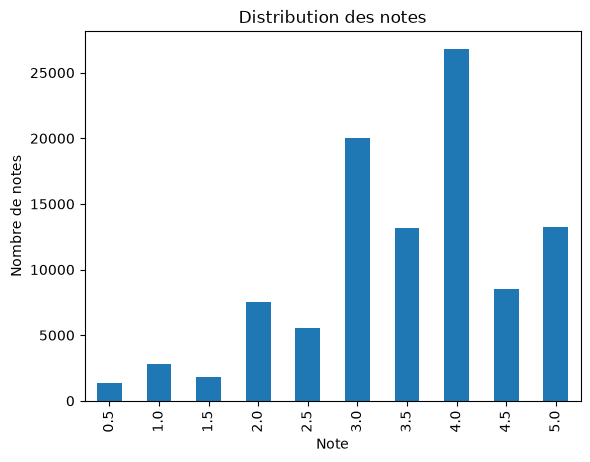

In [35]:
ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution des notes')
plt.xlabel('Note')
plt.ylabel('Nombre de notes')
plt.show()

Graphique : nombre de notes par film (popularité)

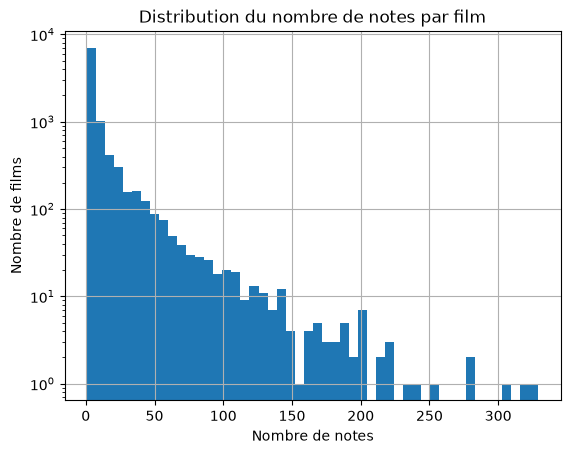

In [36]:
notes_par_film = ratings.groupby('movieId').size()
notes_par_film.hist(bins=50)
plt.title('Distribution du nombre de notes par film')
plt.xlabel('Nombre de notes')
plt.ylabel('Nombre de films')
plt.yscale('log')
plt.show()

Graphique : répartition des genres

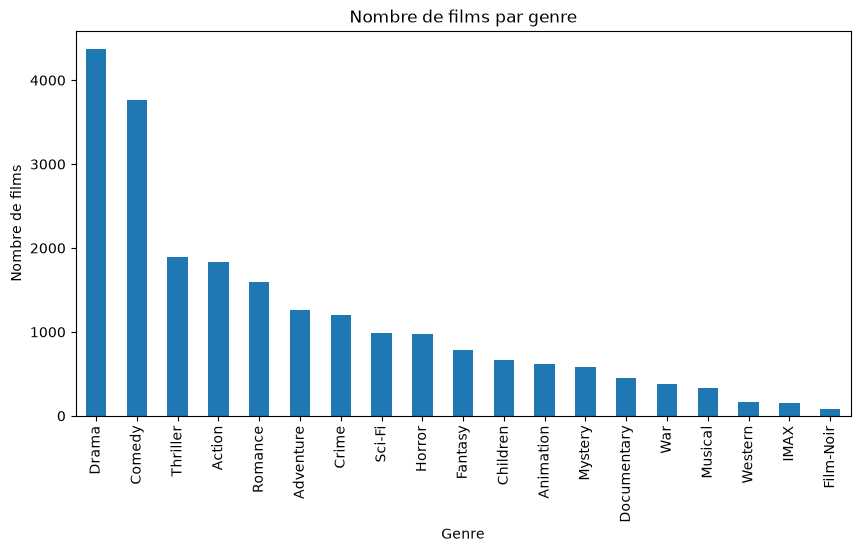

In [37]:
genres_count = movies['genres_list'].explode().value_counts()
genres_count.plot(kind='bar', figsize=(10,5))
plt.title('Nombre de films par genre')
plt.xlabel('Genre')
plt.ylabel('Nombre de films')
plt.show()

Top 10 des films les plus notés 

In [39]:
top_films = ratings.groupby('movieId').size().sort_values(ascending=False).head(10)

top_films_df = movies.set_index('movieId').loc[top_films.index, ['titre']].copy()
top_films_df['nombre_de_notes'] = top_films.values

print(top_films_df)

                                      titre  nombre_de_notes
movieId                                                     
356                            Forrest Gump              329
318               Shawshank Redemption, The              317
296                            Pulp Fiction              307
593               Silence of the Lambs, The              279
2571                            Matrix, The              278
260      Star Wars: Episode IV - A New Hope              251
480                           Jurassic Park              238
110                              Braveheart              237
589              Terminator 2: Judgment Day              224
527                        Schindler's List              220


Activité par utilisateur : est-ce que quelques utilisateurs notent énormément de films pendant que la majorité en note très peu ?

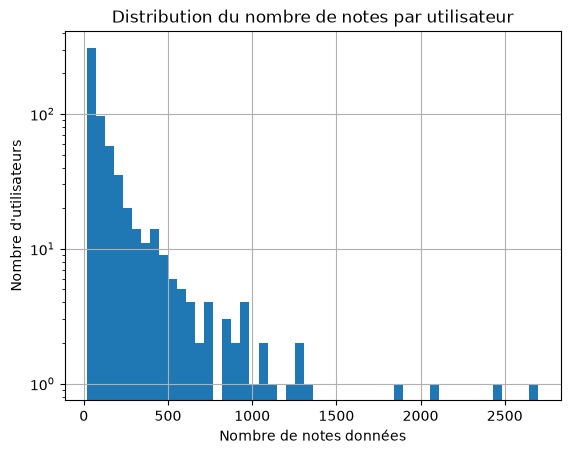

In [40]:
notes_par_user = ratings.groupby('userId').size()
notes_par_user.hist(bins=50)
plt.title('Distribution du nombre de notes par utilisateur')
plt.xlabel('Nombre de notes données')
plt.ylabel("Nombre d'utilisateurs")
plt.yscale('log')
plt.show()

Note moyenne par genre 

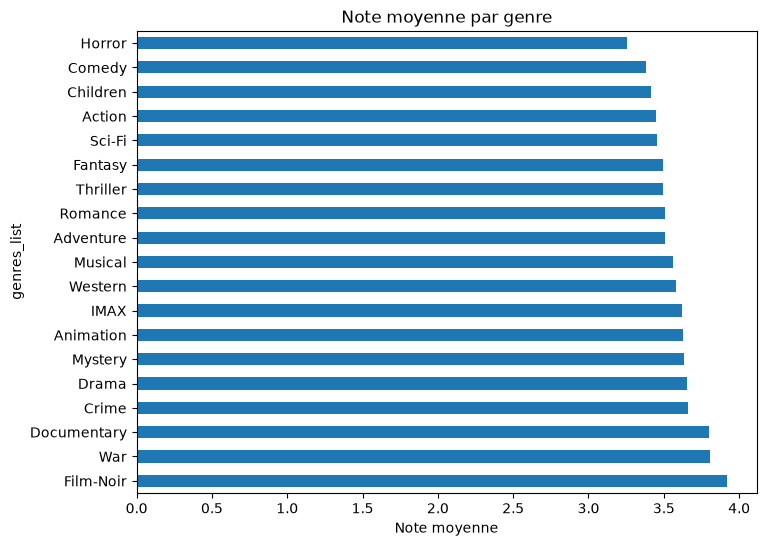

In [41]:
movies_exploded = movies.explode('genres_list')
movies_ratings = movies_exploded.merge(ratings, on='movieId')

note_moyenne_par_genre = movies_ratings.groupby('genres_list')['rating'].mean().sort_values(ascending=False)
note_moyenne_par_genre.plot(kind='barh', figsize=(8,6))
plt.title('Note moyenne par genre')
plt.xlabel('Note moyenne')
plt.show()

Nombre de films sortis par année

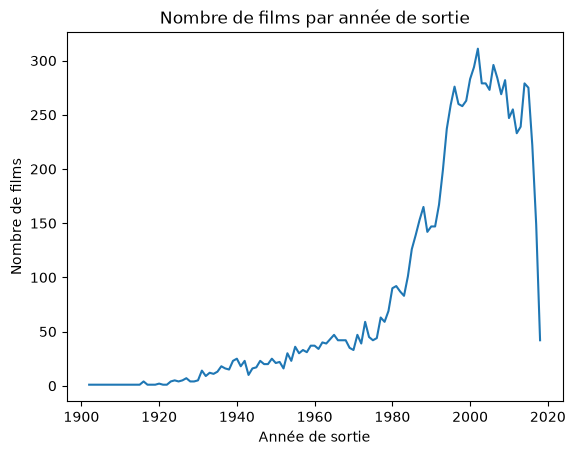

In [42]:
movies['annee'].value_counts().sort_index().plot(kind='line')
plt.title('Nombre de films par année de sortie')
plt.xlabel('Année de sortie')
plt.ylabel('Nombre de films')
plt.show()

Nuage de points : nombre de notes vs note moyenne par film

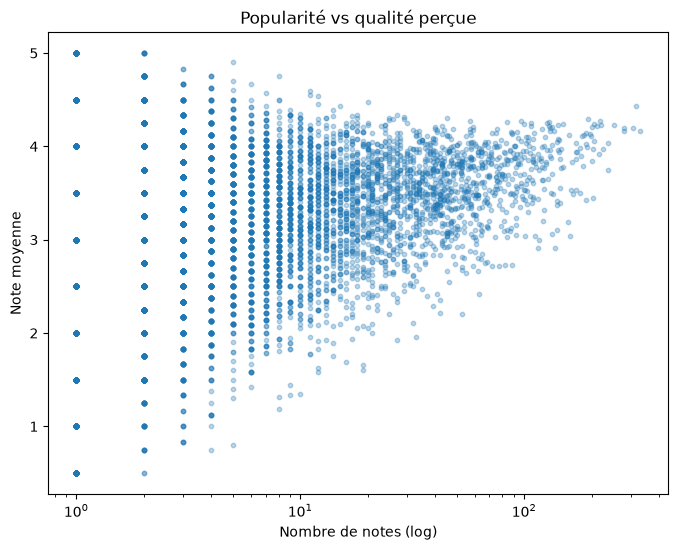

In [43]:
stats_par_film = ratings.groupby('movieId').agg(nb_notes=('rating', 'count'), note_moyenne=('rating', 'mean'))

plt.figure(figsize=(8,6))
plt.scatter(stats_par_film['nb_notes'], stats_par_film['note_moyenne'], alpha=0.3, s=10)
plt.xscale('log')
plt.xlabel('Nombre de notes (log)')
plt.ylabel('Note moyenne')
plt.title('Popularité vs qualité perçue')
plt.show()